# 📚 The Concept Cookbook

This notebook provides a rich library of examples that are **conceptually similar** to the challenges you will face in your exercises. These functions do not solve the exercises for you, but they demonstrate the core programming principles, so you can adapt these ideas to your specific problems. 💡 **For deep dives into the tools used here (NumPy, SciPy, Matplotlib), we strongly encourage studying the [Scientific Python Lectures](https://lectures.scientific-python.org/)!**


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



## 1. Modifying Movement and Physics


### Example: Angular Momentum (Rotational Inertia)
Instead of a simple persistence probability for heading, this approach gives the agent 'angular momentum'. The random walk affects the agent's *turning speed* rather than directly changing the heading, resulting in smooth, curving paths.


In [7]:
def apply_rotational_inertia(current_heading: float, angular_velocity: float, random_torque: float, damping: float) -> tuple:
    """
    Updates heading using a simple physics model of rotational inertia.
    Returns the new heading and the new angular velocity.
    """
    # Dampen the previous rotation (friction)
    new_angular_velocity = angular_velocity * damping
    
    # Add a random push (torque) to the rotation
    new_angular_velocity += random_torque
    
    # Update heading based on how fast the agent is rotating
    new_heading = current_heading + new_angular_velocity
    
    # Normalize heading to [-pi, pi]
    new_heading = (new_heading + np.pi) % (2 * np.pi) - np.pi
    
    return new_heading, new_angular_velocity

# --- Example Execution ---
heading = 0.0
angular_vel = 0.1 # Currently turning slightly left
torque = -0.05    # A push to the right
damping = 0.9     # 10% rotational friction

new_h, new_av = apply_rotational_inertia(heading, angular_vel, torque, damping)
print(f"Old Heading: {heading:.2f}, Old AngVel: {angular_vel:.3f}")
print(f"New Heading: {new_h:.2f}, New AngVel: {new_av:.3f}")



Old Heading: 0.00, Old AngVel: 0.100
New Heading: 0.04, New AngVel: 0.040


### Example: Viscous Boundary Conditions
This example shows how to implement a 'viscous' boundary where agents lose speed when they enter a thick mud zone near the edges.


In [8]:
def apply_viscous_boundary(x: float, y: float, width: float, height: float, current_speed: float) -> float:
    """
    Reduces the agent's speed by 50% if they are within 10 units of the arena's edges.
    """
    margin = 10.0
    if x < margin or x > (width - margin) or y < margin or y > (height - margin):
        return current_speed * 0.5
    return current_speed

# --- Example Execution ---
speed = 2.0
print(f"Speed in center: {apply_viscous_boundary(50, 50, 100, 100, speed)}")
print(f"Speed near edge: {apply_viscous_boundary(5, 50, 100, 100, speed)}")



Speed in center: 2.0
Speed near edge: 1.0


### Example: Terrain Friction Penalty


In [9]:
def calculate_terrain_speed(base_speed: float, terrain_friction_map: np.ndarray, x: int, y: int) -> float:
    """
    Reads the friction coefficient from a 2D map and reduces speed.
    """
    # Ensure coordinates are within bounds
    x = np.clip(x, 0, terrain_friction_map.shape[0]-1)
    y = np.clip(y, 0, terrain_friction_map.shape[1]-1)
    
    friction = terrain_friction_map[x, y]
    return base_speed * (1.0 - friction)

# --- Example Execution ---
terrain = np.zeros((10, 10))
terrain[5, 5] = 0.8  # High friction patch
print(f"Speed on normal ground: {calculate_terrain_speed(1.0, terrain, 0, 0)}")
print(f"Speed on high friction: {calculate_terrain_speed(1.0, terrain, 5, 5)}")



Speed on normal ground: 1.0
Speed on high friction: 0.19999999999999996


## 2. Analyzing Trajectories and Data


### Example: Trajectory Center of Mass
This function calculates how the 'center of mass' of a trajectory drifts over time.


In [10]:
def compute_trajectory_drift(trajectory: list) -> float:
    """
    Calculates the distance from the starting point to the center of mass of the entire trajectory.
    """
    traj_arr = np.array(trajectory)
    start_point = traj_arr[0]
    center_of_mass = np.mean(traj_arr, axis=0)
    drift_distance = np.linalg.norm(center_of_mass - start_point)
    return drift_distance

# --- Example Execution ---
# A dummy trajectory moving roughly diagonally
dummy_traj = [(0,0), (1,1.5), (2,1.8), (3,3.2), (4,4.1)]
print(f"Trajectory Drift Distance: {compute_trajectory_drift(dummy_traj):.2f}")



Trajectory Drift Distance: 2.91


### Example: Fitting an Exponential Decay
This shows how to fit an exponential decay curve to data using scipy.


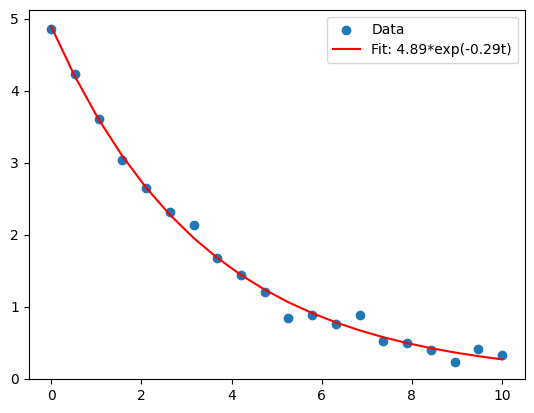

In [11]:
def fit_exponential_decay(time_steps: np.ndarray, values: np.ndarray):
    """
    Fits a curve of the form y = A * exp(-B * t) to the data.
    """
    def decay_func(t, A, B):
        return A * np.exp(-B * t)
        
    # p0 is the initial guess for A and B
    popt, pcov = curve_fit(decay_func, time_steps, values, p0=(1.0, 0.1))
    return popt

# --- Example Execution ---
t = np.linspace(0, 10, 20)
v = 5.0 * np.exp(-0.3 * t) + np.random.normal(0, 0.1, len(t)) # Noisy data
A, B = fit_exponential_decay(t, v)

plt.scatter(t, v, label="Data")
plt.plot(t, A * np.exp(-B * t), color='red', label=f"Fit: {A:.2f}*exp(-{B:.2f}t)")
plt.legend()
plt.show()



### Example: Analyzing Step Length Distribution
This function plots a histogram of step lengths against a theoretical Normal distribution.


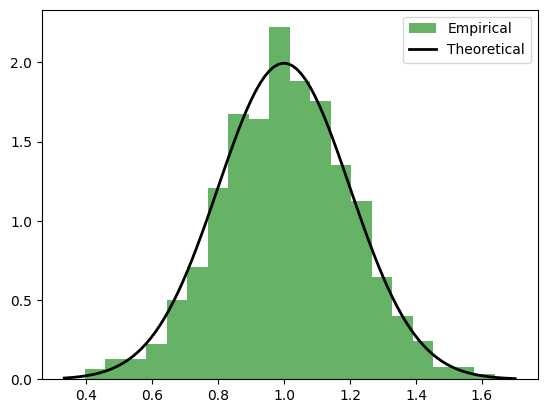

In [19]:
def plot_step_length_distribution(step_lengths: np.ndarray, theoretical_mean: float, theoretical_std: float):
    """
    Plots a histogram of empirical step lengths and overlays a theoretical normal PDF.
    """
    from scipy.stats import norm
    
    plt.hist(step_lengths, bins=20, density=True, alpha=0.6, color='g', label="Empirical")
    
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, theoretical_mean, theoretical_std)
    plt.plot(x, p, 'k', linewidth=2, label="Theoretical")
    plt.legend()
    plt.show()

# --- Example Execution ---
steps = np.random.normal(loc=1.0, scale=0.2, size=1000)
plot_step_length_distribution(steps, 1.0, 0.2)



## 3. States, Memory, and Environment Interactions


### Example: State Change Based on Energy
This changes the agent's behavior state when energy drops below a threshold.


In [13]:
def check_rest_state(current_energy: float, rest_threshold: float) -> str:
    """
    Returns 'resting' if energy is too low, otherwise 'active'.
    """
    if current_energy < rest_threshold:
        return 'resting'
    return 'active'

# --- Example Execution ---
print(f"Energy 50: {check_rest_state(50, 20)}")
print(f"Energy 10: {check_rest_state(10, 20)}")



Energy 50: active
Energy 10: resting


### Example: Spatial Memory for High-Quality Patches
This function uses a dictionary to remember and navigate towards the highest quality patch found so far.


In [14]:
def vector_to_best_remembered_patch(memory_dict: dict, current_pos: tuple) -> tuple:
    """
    memory_dict maps coordinates (x,y) to quality scores.
    Returns a directional vector towards the best patch, or (0,0) if memory is empty.
    """
    if not memory_dict:
        return (0.0, 0.0)
        
    best_pos = max(memory_dict, key=memory_dict.get)
    dx = best_pos[0] - current_pos[0]
    dy = best_pos[1] - current_pos[1]
    
    # Normalize the vector
    mag = np.hypot(dx, dy)
    if mag == 0:
        return (0.0, 0.0)
    return (dx/mag, dy/mag)

# --- Example Execution ---
memory = {(10, 10): 5, (50, 50): 100, (20, 80): 10}
curr = (15, 15)
vec = vector_to_best_remembered_patch(memory, curr)
print(f"Moving towards best patch with vector: {vec[0]:.2f}, {vec[1]:.2f}")



Moving towards best patch with vector: 0.71, 0.71


### Example: Shelter Regeneration Zone


In [15]:
def apply_shelter_regeneration(x: float, y: float, shelter_x_min: float, shelter_x_max: float, current_health: float) -> float:
    """
    Agents inside the vertical strip [shelter_x_min, shelter_x_max] gain 5 health points.
    """
    if shelter_x_min <= x <= shelter_x_max:
        return min(current_health + 5, 100) # Cap at 100
    return current_health

# --- Example Execution ---
print(f"Health outside shelter: {apply_shelter_regeneration(10, 50, 20, 40, 50)}")
print(f"Health inside shelter: {apply_shelter_regeneration(30, 50, 20, 40, 50)}")



Health outside shelter: 50
Health inside shelter: 55


## 4. Grid Manipulations (Analogous to Stigmergy)


### Example: Wind-Biased Diffusion


In [20]:
def asymmetric_rightward_diffusion(grid: np.ndarray, diffusion_rate: float) -> np.ndarray:
    """
    A simple grid manipulation where values leak to the right neighbor rather than in all directions.
    """
    new_grid = np.copy(grid)
    for x in range(grid.shape[0] - 1):
        for y in range(grid.shape[1]):
            transfer = grid[x, y] * diffusion_rate
            new_grid[x, y] -= transfer
            new_grid[x+1, y] += transfer
    return new_grid

# --- Example Execution ---
g = np.zeros((5, 5))
g[2, 2] = 100.0
print("Original Grid:\n", g)
print("\nAfter Rightward Diffusion:\n", asymmetric_rightward_diffusion(g, 0.5))



Original Grid:
 [[  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0. 100.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]

After Rightward Diffusion:
 [[ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0. 50.  0.  0.]
 [ 0.  0. 50.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


### Example: Counting Disconnected Grid Blobs
Instead of computing trail width, this uses `skimage` to count the number of fragmented, disconnected 'blobs' in a grid.


In [17]:
def count_isolated_blobs(grid: np.ndarray, threshold: float) -> int:
    """
    Binarizes the grid and counts how many distinct patches exist.
    Useful for analyzing if a trail has broken into fragments.
    """
    from skimage.measure import label
    
    binary_grid = grid > threshold
    labeled_grid, num_features = label(binary_grid, return_num=True)
    return num_features

# --- Example Execution ---
g = np.zeros((10, 10))
g[1:3, 1:3] = 2.0 # Blob 1
g[7:9, 7:9] = 2.0 # Blob 2
print(f"Number of distinct blobs: {count_isolated_blobs(g, 1.0)}")



Number of distinct blobs: 2


### Example: Synergistic Grid Combination
This shows how to combine two different grids to create a 'synergy' map where high values only exist if BOTH grids have high values.


In [21]:
def calculate_synergy_map(grid_a: np.ndarray, grid_b: np.ndarray) -> np.ndarray:
    """
    Multiplies two grids together. 
    A cell only has a high synergy score if it has a high score in BOTH grid_a and grid_b.
    """
    return grid_a * grid_b

# --- Example Execution ---
ga = np.array([[0, 1], [1, 1]])
gb = np.array([[1, 1], [0, 1]])
print("Synergy Map:\n", calculate_synergy_map(ga, gb))



Synergy Map:
 [[0 1]
 [0 1]]
